<a href="https://colab.research.google.com/github/ri0602/daa-lab/blob/main/daa_lab_2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#program 1

def union_intersection(A, B):

    i = 0
    j = 0

    union = []
    intersection = []

    while i < len(A) and j < len(B):

        if A[i] < B[j]:
            union.append(A[i])
            i += 1

        elif A[i] > B[j]:
            union.append(B[j])
            j += 1

        else:
            union.append(A[i])
            intersection.append(A[i])

            i += 1
            j += 1

    # Add remaining elements of A
    while i < len(A):
        union.append(A[i])
        i += 1

    # Add remaining elements of B
    while j < len(B):
        union.append(B[j])
        j += 1

    return union, intersection


# Input arrays
A = [1, 2, 4, 5]
B = [2, 4, 6]

# Find union and intersection
union, intersection = union_intersection(A, B)

# Display results
print("Array A:", A)
print("Array B:", B)
print("Union:", union)
print("Intersection:", intersection)

Array A: [1, 2, 4, 5]
Array B: [2, 4, 6]
Union: [1, 2, 4, 5, 6]
Intersection: [2, 4]


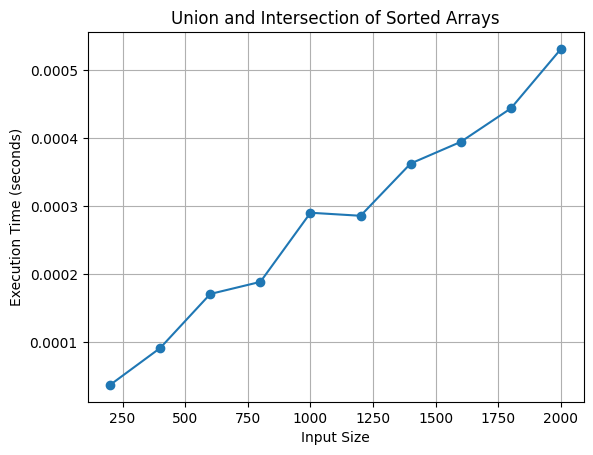

In [4]:
import matplotlib.pyplot as plt
import time

sizes = [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
times = []

for n in sizes:

    # Sorted arrays of equal size
    A = list(range(0, n))
    B = list(range(n, 2 * n))

    start = time.perf_counter()

    for k in range(10):
        union_intersection(A, B)

    end = time.perf_counter()

    times.append((end - start) / 10)


plt.plot(sizes, times, marker='o')

plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Union and Intersection of Sorted Arrays")

plt.grid(True)
plt.show()

In [5]:
# program 2
def search_rotated_array(arr, target):

    left = 0
    right = len(arr) - 1

    while left <= right:

        mid = (left + right) // 2

        # Target found
        if arr[mid] == target:
            return mid

        # Check if left half is sorted
        if arr[left] <= arr[mid]:

            # Target lies in left sorted half
            if arr[left] <= target < arr[mid]:
                right = mid - 1

            # Target lies in right half
            else:
                left = mid + 1

        # Otherwise, right half is sorted
        else:

            # Target lies in right sorted half
            if arr[mid] < target <= arr[right]:
                left = mid + 1

            # Target lies in left half
            else:
                right = mid - 1

    return -1


# Input
arr = [6, 7, 8, 1, 2, 3, 4]
target = 2

# Search
result = search_rotated_array(arr, target)

print("Array:", arr)
print("Target:", target)
print("Index:", result)

Array: [6, 7, 8, 1, 2, 3, 4]
Target: 2
Index: 4


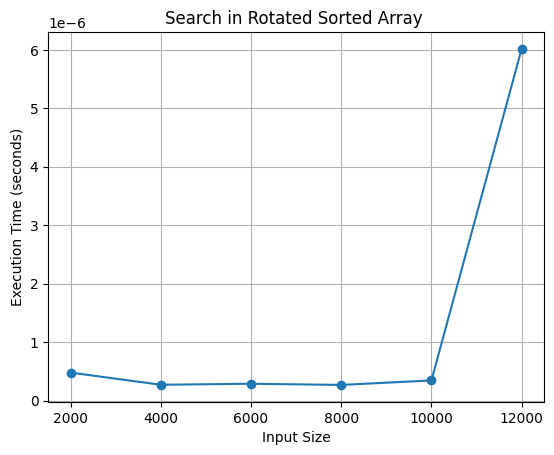

In [12]:
import matplotlib.pyplot as plt
import time

sizes = [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
times = []

for n in sizes:

    arr = list(range(n))

    # Rotate the sorted array
    arr = arr[n // 2:] + arr[:n // 2]

    target = n - 1

    start = time.perf_counter()

    for k in range(100):
        search_rotated_array(arr, target)

    end = time.perf_counter()

    times.append((end - start) / 100)


plt.plot(sizes, times, marker='o')

plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Search in Rotated Sorted Array ")
plt.grid(True)
plt.show()

In [13]:
#merge sort

def merge_sort(arr):

    # If array has 0 or 1 element, it is already sorted
    if len(arr) <= 1:
        return arr

    # Find middle
    mid = len(arr) // 2

    # Divide the array
    left = arr[:mid]
    right = arr[mid:]

    # Recursively sort both halves
    left = merge_sort(left)
    right = merge_sort(right)

    # Merge sorted halves
    return merge(left, right)


def merge(left, right):

    result = []
    i = 0
    j = 0

    # Compare elements from both arrays
    while i < len(left) and j < len(right):

        if left[i] < right[j]:
            result.append(left[i])
            i += 1

        else:
            result.append(right[j])
            j += 1

    # Add remaining elements
    while i < len(left):
        result.append(left[i])
        i += 1

    while j < len(right):
        result.append(right[j])
        j += 1

    return result


# Input
arr = [9, 3, 7, 1, 6]

# Sort the array
sorted_array = merge_sort(arr)

print("Original Array:", arr)
print("Sorted Array:", sorted_array)

Original Array: [9, 3, 7, 1, 6]
Sorted Array: [1, 3, 6, 7, 9]


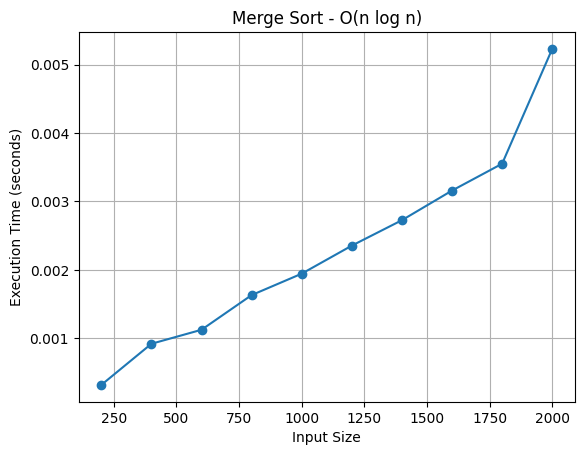

In [14]:
import matplotlib.pyplot as plt
import time
import random

sizes = [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
times = []

for n in sizes:

    # Create an unsorted array
    arr = list(range(n))
    random.shuffle(arr)

    start = time.perf_counter()

    for k in range(10):
        merge_sort(arr)

    end = time.perf_counter()

    times.append((end - start) / 10)


plt.plot(sizes, times, marker='o')

plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Merge Sort - O(n log n)")
plt.grid(True)
plt.show()

In [15]:
def merge_sort(arr):

    if len(arr) <= 1:
        return arr, 0

    mid = len(arr) // 2

    left, left_count = merge_sort(arr[:mid])
    right, right_count = merge_sort(arr[mid:])

    merged, merge_count = merge(left, right)

    total_count = left_count + right_count + merge_count

    return merged, total_count


def merge(left, right):

    result = []

    i = 0
    j = 0
    count = 0

    while i < len(left) and j < len(right):

        if left[i] <= right[j]:

            result.append(left[i])
            i += 1

        else:

            result.append(right[j])

            # All remaining elements in left
            # are greater than right[j]
            count += len(left) - i

            j += 1

    # Add remaining elements
    while i < len(left):
        result.append(left[i])
        i += 1

    while j < len(right):
        result.append(right[j])
        j += 1

    return result, count


# Input
arr = [8, 4, 2, 1]

# Count inversions
sorted_array, inversions = merge_sort(arr)

print("Array:", arr)
print("Sorted Array:", sorted_array)
print("Number of Inversions:", inversions)

Array: [8, 4, 2, 1]
Sorted Array: [1, 2, 4, 8]
Number of Inversions: 6


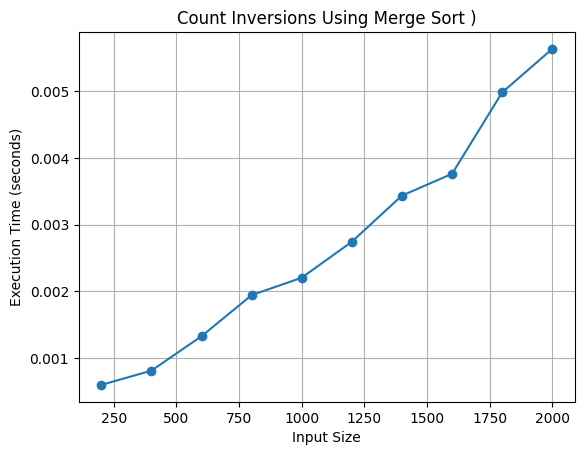

In [18]:
import matplotlib.pyplot as plt
import time
import random

sizes = [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
times = []

for n in sizes:

    # Create an unsorted array
    arr = list(range(n))
    random.shuffle(arr)

    start = time.perf_counter()

    for k in range(10):
        merge_sort(arr)

    end = time.perf_counter()

    times.append((end - start) / 10)


plt.plot(sizes, times, marker='o')

plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Count Inversions Using Merge Sort )")
plt.grid(True)
plt.show()